# Lab 3.1 — Audio Classification: CNN vs. Transformer
Membandingkan 2D-CNN kecil vs Tiny Transformer Encoder pada Mel-spectrogram, memakai subset SpeechCommands (10 keywords).

In [2]:
!pip -q install torchaudio scikit-learn
import torch, torchaudio
print(torch.__version__, torchaudio.__version__, torch.cuda.is_available())

2.11.0+cu128 2.11.0+cu128 True


In [3]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split
from torchaudio.datasets import SPEECHCOMMANDS
import time, os

SAMPLE_RATE = 16000
N_MELS = 80
N_FFT = 400
HOP_LENGTH = 160
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASSES = ['yes','no','up','down','left','right','on','off','stop','go']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

mel_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
to_db = T.AmplitudeToDB()

def preprocess(waveform, sr):
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
    target_len = SAMPLE_RATE
    if waveform.shape[-1] < target_len:
        waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.shape[-1]))
    else:
        waveform = waveform[..., :target_len]
    mel = to_db(mel_transform(waveform))
    return mel

## Dataset wrapper: filter hanya 10 keyword target

In [4]:
os.makedirs('./data', exist_ok=True)

class KeywordSubset(Dataset):
    def __init__(self, subset='training'):
        base = SPEECHCOMMANDS('./data', download=True, subset=subset)
        self.items = []
        for i in range(len(base)):
            waveform, sr, label, *_ = base[i]
            if label in CLASS2IDX:
                self.items.append((waveform, sr, CLASS2IDX[label]))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        waveform, sr, label = self.items[idx]
        mel = preprocess(waveform, sr)
        return mel, label

print('Memuat dataset (bisa memakan waktu beberapa menit saat pertama kali)...')
train_full = KeywordSubset('training')
val_ds = KeywordSubset('validation')
print(f'Train: {len(train_full)} | Val: {len(val_ds)}')

train_loader = DataLoader(train_full, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

Memuat dataset (bisa memakan waktu beberapa menit saat pertama kali)...


100%|██████████| 2.26G/2.26G [00:37<00:00, 64.4MB/s]


Train: 30769 | Val: 3703


## Model A: 2D-CNN & Model B: Tiny Transformer

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).squeeze(-1).squeeze(-1)
        return self.classifier(x)


class TinyAudioTransformer(nn.Module):
    def __init__(self, n_mels=80, d_model=128, nhead=4, num_layers=2, num_classes=10, max_len=101):
        super().__init__()
        self.input_proj = nn.Linear(n_mels, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=256, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1)
        B, Tn, _ = x.shape
        x = self.input_proj(x)
        pos = torch.arange(Tn, device=x.device)
        x = x + self.pos_emb(pos).unsqueeze(0)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

In [6]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)
    start = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for mel, label in train_loader:
            mel, label = mel.to(DEVICE), label.to(DEVICE)
            optimizer.zero_grad()
            out = model(mel)
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == label).sum().item()
            total += label.size(0)
        val_acc = evaluate(model, val_loader)
        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {correct/total:.3f} | Val Acc: {val_acc:.3f}')
    elapsed = time.time() - start
    print(f'Training time: {elapsed:.1f}s')
    return elapsed


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for mel, label in loader:
            mel, label = mel.to(DEVICE), label.to(DEVICE)
            correct += (model(mel).argmax(1) == label).sum().item()
            total += label.size(0)
    return correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
cnn_model = SmallCNN()
trans_model = TinyAudioTransformer()
print(f'CNN params: {count_params(cnn_model):,}')
print(f'Transformer params: {count_params(trans_model):,}')

print('\n--- Training CNN ---')
cnn_time = train_model(cnn_model, train_loader, val_loader)
cnn_acc = evaluate(cnn_model, val_loader)

print('\n--- Training Transformer ---')
trans_time = train_model(trans_model, train_loader, val_loader)
trans_acc = evaluate(trans_model, val_loader)

CNN params: 94,410
Transformer params: 289,546

--- Training CNN ---
Epoch   5 | Loss: 0.6129 | Train Acc: 0.811 | Val Acc: 0.758
Epoch  10 | Loss: 0.3863 | Train Acc: 0.880 | Val Acc: 0.846
Epoch  15 | Loss: 0.2939 | Train Acc: 0.908 | Val Acc: 0.850
Epoch  20 | Loss: 0.2380 | Train Acc: 0.925 | Val Acc: 0.885
Training time: 809.9s

--- Training Transformer ---
Epoch   5 | Loss: 0.5430 | Train Acc: 0.819 | Val Acc: 0.810
Epoch  10 | Loss: 0.3603 | Train Acc: 0.882 | Val Acc: 0.883
Epoch  15 | Loss: 0.3113 | Train Acc: 0.897 | Val Acc: 0.900
Epoch  20 | Loss: 0.2974 | Train Acc: 0.900 | Val Acc: 0.899
Training time: 737.2s


## Deliverable 1: tabel perbandingan

In [8]:
import pandas as pd
df = pd.DataFrame({
    'Model': ['2D-CNN', 'Tiny Transformer'],
    'Val Accuracy': [cnn_acc, trans_acc],
    'Training Time (s)': [cnn_time, trans_time],
    'Params': [count_params(cnn_model), count_params(trans_model)],
})
df

,Model,Val Accuracy,Training Time (s),Params
0,2D-CNN,0.884688,809.883101,94410
1,Tiny Transformer,0.899001,737.186736,289546


## Deliverable 2: Confusion matrix untuk model terbaik

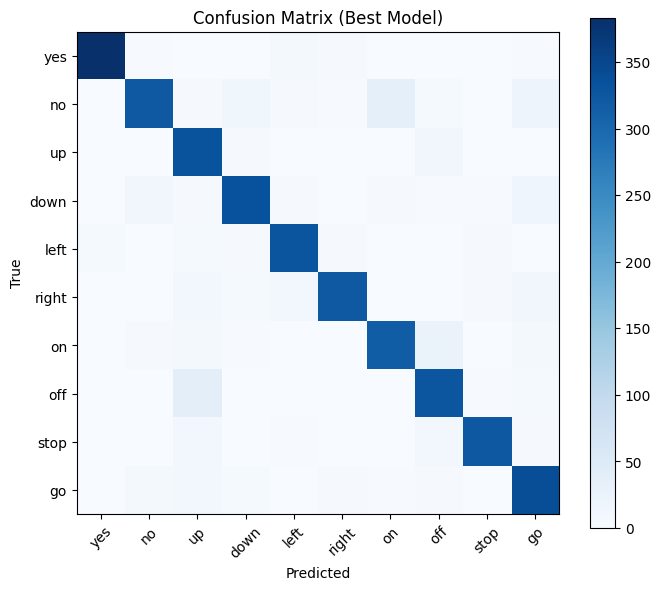

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

best_model = cnn_model if cnn_acc >= trans_acc else trans_model
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for mel, label in val_loader:
        mel = mel.to(DEVICE)
        preds = best_model(mel).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(label.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(10), CLASSES, rotation=45)
plt.yticks(range(10), CLASSES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Best Model)')
plt.colorbar()
plt.tight_layout(); plt.savefig('lab31_confusion_matrix.png', dpi=150); plt.show()